<a href="https://colab.research.google.com/github/aniray2908/satellite-esg-risk-engine/blob/main/experiments/python/ceri/ceri_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 4 — Corporate Environmental Risk Index (CERI v2)

## Portfolio Expansion & Distribution Stabilization

CERI v2 extends the risk scoring framework from a two-asset prototype
to a four-asset portfolio model.

The objective is to evaluate statistical stability, clustering behavior,
and distributional properties under expanded asset coverage.


## Why Was CERI v2 Necessary?

CERI v1 was constructed using two assets:

- Carajás
- Gevra

While sufficient for validating feature design,
the limited sample size resulted in:

- Binary min-max normalization
- Extreme z-score contrast
- Trivial clustering behavior

To stabilize statistical interpretation and enable meaningful portfolio modeling,
two additional mining assets were added:

- Bingham Canyon (USA)
- Grasberg Mine (Indonesia)

CERI v2 evaluates model behavior across a more diverse exposure distribution.


In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
carajas = pd.read_csv("/content/drive/MyDrive/carajas_pit_centered_full_year_v2_1.csv")
gevra = pd.read_csv("/content/drive/MyDrive/gevra_pit_centered_full_year_v1.csv")
bingham = pd.read_csv("/content/drive/MyDrive/bingham_pit_centered_full_year_v1.csv")
grasberg = pd.read_csv("/content/drive/MyDrive/grasberg_pit_centered_full_year_v1.csv")

carajas["asset"] = "Carajás"
gevra["asset"] = "Gevra"
bingham["asset"] = "Bingham"
grasberg["asset"] = "Grasberg"

df = pd.concat([carajas, gevra, bingham, grasberg], ignore_index=True)

df.head()

,system:index,image_count,low_ndvi_fraction,mean_ndvi,year,.geo,asset
0,0,101,0.865651,0.059416,2019,"{""type"":""MultiPoint"",""coordinates"":[]}",Carajás
1,1,84,0.921274,0.058572,2020,"{""type"":""MultiPoint"",""coordinates"":[]}",Carajás
2,2,89,0.974743,0.012760,2021,"{""type"":""MultiPoint"",""coordinates"":[]}",Carajás
3,3,83,0.954150,0.029671,2022,"{""type"":""MultiPoint"",""coordinates"":[]}",Carajás
4,4,95,0.970843,0.015329,2023,"{""type"":""MultiPoint"",""coordinates"":[]}",Carajás


In [5]:
feature_df = df.groupby("asset").agg({
    "low_ndvi_fraction": ["mean", "var"],
    "mean_ndvi": "mean"
})

feature_df.columns = ["F1_exposure_intensity",
                      "low_ndvi_variance",
                      "mean_ndvi"]

feature_df.reset_index(inplace=True)

# F2: Vegetation Suppression
feature_df["F2_vegetation_suppression"] = 1 - feature_df["mean_ndvi"]

# F3: Persistence (inverse normalized variance)
max_var = feature_df["low_ndvi_variance"].max()
min_var = feature_df["low_ndvi_variance"].min()

feature_df["F3_persistence_raw"] = 1 - (
    (feature_df["low_ndvi_variance"] - min_var) /
    (max_var - min_var + 1e-9)
)

feature_df

,asset,F1_exposure_intensity,low_ndvi_variance,mean_ndvi,F2_vegetation_suppression,F3_persistence_raw
0,Bingham,0.999922,2.805335e-09,0.021179,0.978821,1.000000e+00
1,Carajás,0.937332,2.050342e-03,0.035150,0.964850,4.877238e-07
2,Gevra,0.684294,6.057728e-05,0.193744,0.806256,9.704564e-01
3,Grasberg,0.999596,8.161065e-07,-0.011148,1.011148,9.996033e-01


## Feature Summary

F1 — Exposure Intensity  
Mean proportion of exposed land (NDVI < 0.2).

F2 — Vegetation Suppression  
Inverted mean NDVI.

F3 — Persistence  
Inverse of normalized variance in exposure.

With four assets, feature spread is now more informative
and no longer binary.


In [6]:
z_features = ["F1_exposure_intensity",
              "F2_vegetation_suppression",
              "F3_persistence_raw"]

for col in z_features:
    mean_val = feature_df[col].mean()
    std_val = feature_df[col].std()
    feature_df[col + "_z"] = (
        (feature_df[col] - mean_val) /
        (std_val + 1e-9)
    )

feature_df

,asset,F1_exposure_intensity,low_ndvi_variance,mean_ndvi,F2_vegetation_suppression,F3_persistence_raw,F1_exposure_intensity_z,F2_vegetation_suppression_z,F3_persistence_raw_z
0,Bingham,0.999922,2.805335e-09,0.021179,0.978821,1.000000e+00,0.629904,0.421693,0.519958
1,Carajás,0.937332,2.050342e-03,0.035150,0.964850,4.877238e-07,0.213303,0.268879,-1.499415
2,Gevra,0.684294,6.057728e-05,0.193744,0.806256,9.704564e-01,-1.470942,-1.465874,0.460299
3,Grasberg,0.999596,8.161065e-07,-0.011148,1.011148,9.996033e-01,0.627735,0.775302,0.519157


In [7]:
w1, w2, w3 = 0.5, 0.3, 0.2

feature_df["CERI_z"] = (
    w1 * feature_df["F1_exposure_intensity_z"] +
    w2 * feature_df["F2_vegetation_suppression_z"] +
    w3 * feature_df["F3_persistence_raw_z"]
)

feature_df.sort_values("CERI_z", ascending=False)

,asset,F1_exposure_intensity,low_ndvi_variance,mean_ndvi,F2_vegetation_suppression,F3_persistence_raw,F1_exposure_intensity_z,F2_vegetation_suppression_z,F3_persistence_raw_z,CERI_z
3,Grasberg,0.999596,8.161065e-07,-0.011148,1.011148,9.996033e-01,0.627735,0.775302,0.519157,0.650290
0,Bingham,0.999922,2.805335e-09,0.021179,0.978821,1.000000e+00,0.629904,0.421693,0.519958,0.545452
1,Carajás,0.937332,2.050342e-03,0.035150,0.964850,4.877238e-07,0.213303,0.268879,-1.499415,-0.112568
2,Gevra,0.684294,6.057728e-05,0.193744,0.806256,9.704564e-01,-1.470942,-1.465874,0.460299,-1.083173


## Interpretation of CERI_z (v2)

CERI_z now reflects relative deviation from portfolio mean.

Positive values → above-average environmental exposure  
Negative values → below-average exposure  

Unlike v1, mid-range values should now emerge,
reflecting a more stable distribution.


In [8]:
cluster_features = feature_df[[
    "F1_exposure_intensity_z",
    "F2_vegetation_suppression_z",
    "F3_persistence_raw_z"
]]

kmeans = KMeans(n_clusters=2, random_state=42)
feature_df["risk_cluster"] = kmeans.fit_predict(cluster_features)

feature_df

,asset,F1_exposure_intensity,low_ndvi_variance,mean_ndvi,F2_vegetation_suppression,F3_persistence_raw,F1_exposure_intensity_z,F2_vegetation_suppression_z,F3_persistence_raw_z,CERI_z,risk_cluster
0,Bingham,0.999922,2.805335e-09,0.021179,0.978821,1.000000e+00,0.629904,0.421693,0.519958,0.545452,0
1,Carajás,0.937332,2.050342e-03,0.035150,0.964850,4.877238e-07,0.213303,0.268879,-1.499415,-0.112568,0
2,Gevra,0.684294,6.057728e-05,0.193744,0.806256,9.704564e-01,-1.470942,-1.465874,0.460299,-1.083173,1
3,Grasberg,0.999596,8.161065e-07,-0.011148,1.011148,9.996033e-01,0.627735,0.775302,0.519157,0.650290,0


In [9]:
score = silhouette_score(cluster_features, feature_df["risk_cluster"])
score

np.float64(0.37383291076400604)

## Cluster Evaluation

Silhouette score measures separation quality:

- Closer to 1 → well-separated clusters
- Near 0 → overlapping clusters
- Negative → poor clustering

With four assets, clustering becomes non-trivial
and reflects meaningful exposure segmentation.

In [10]:
cluster_means = feature_df.groupby("risk_cluster")["CERI_z"].mean()
high_risk_cluster = cluster_means.idxmax()

feature_df["risk_tier"] = feature_df["risk_cluster"].apply(
    lambda x: "High Risk" if x == high_risk_cluster else "Moderate Risk"
)

feature_df[["asset", "CERI_z", "risk_tier"]]

,asset,CERI_z,risk_tier
0,Bingham,0.545452,High Risk
1,Carajás,-0.112568,High Risk
2,Gevra,-1.083173,Moderate Risk
3,Grasberg,0.650290,High Risk


## CERI v2 — Model Evolution Summary

Compared to v1, CERI v2 demonstrates:

- Stabilized feature distribution
- Non-binary z-score scaling
- Meaningful clustering behavior
- Portfolio-level segmentation
- Improved statistical interpretability

The framework now supports:

- Additional asset integration
- Weight optimization
- Advanced clustering methods
- Multi-signal expansion




---



---

# Phase 5 — Weight Sensitivity & Ranking Stability Analysis

The CERI score is a weighted composite of three standardized features:

CERI = w1 * F1_z + w2 * F2_z + w3 * F3_z

While initial weights were heuristically chosen, it is important to assess:

- How sensitive rankings are to weight changes
- Whether asset ordering is stable
- Which assets are robust vs sensitive

This section performs a structured sensitivity analysis
using a predefined weight grid.

In [23]:
import itertools
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# Structured weight grid (sum to 1)
weight_grid = [
    (0.5, 0.3, 0.2),  # baseline
    (0.6, 0.2, 0.2),
    (0.4, 0.4, 0.2),
    (0.4, 0.3, 0.3),
    (0.5, 0.4, 0.1),
    (0.33, 0.33, 0.34)
]

# weight_grid

extreme_weights = [
    (0.8, 0.1, 0.1),
    (0.1, 0.8, 0.1),
    (0.1, 0.1, 0.8),
    (0.7, 0.2, 0.1),
    (0.2, 0.7, 0.1),
    (0.2, 0.1, 0.7)
]

weight_grid_extended = weight_grid + extreme_weights

In [24]:
results = []

for w1, w2, w3 in weight_grid_extended:
    temp = feature_df.copy()

    temp["CERI_temp"] = (
        w1 * temp["F1_exposure_intensity_z"] +
        w2 * temp["F2_vegetation_suppression_z"] +
        w3 * temp["F3_persistence_raw_z"]
    )

    temp["rank"] = temp["CERI_temp"].rank(ascending=False)

    temp["w1"] = w1
    temp["w2"] = w2
    temp["w3"] = w3

    results.append(temp[["asset", "CERI_temp", "rank", "w1", "w2", "w3"]])

sensitivity_df = pd.concat(results, ignore_index=True)

sensitivity_df.head()

,asset,CERI_temp,rank,w1,w2,w3
0,Bingham,0.545452,2.0,0.5,0.3,0.2
1,Carajás,-0.112568,3.0,0.5,0.3,0.2
2,Gevra,-1.083173,4.0,0.5,0.3,0.2
3,Grasberg,0.650290,1.0,0.5,0.3,0.2
4,Bingham,0.566273,2.0,0.6,0.2,0.2


In [25]:
baseline = sensitivity_df[
    (sensitivity_df["w1"] == 0.5) &
    (sensitivity_df["w2"] == 0.3) &
    (sensitivity_df["w3"] == 0.2)
].sort_values("rank")

baseline_ranking = baseline["asset"].tolist()
baseline_ranking

['Grasberg', 'Bingham', 'Carajás', 'Gevra']

In [26]:
correlation_results = []

for w1, w2, w3 in weight_grid_extended:
    subset = sensitivity_df[
        (sensitivity_df["w1"] == w1) &
        (sensitivity_df["w2"] == w2) &
        (sensitivity_df["w3"] == w3)
    ].sort_values("asset")

    baseline_subset = sensitivity_df[
        (sensitivity_df["w1"] == 0.5) &
        (sensitivity_df["w2"] == 0.3) &
        (sensitivity_df["w3"] == 0.2)
    ].sort_values("asset")

    corr, _ = spearmanr(
        baseline_subset["rank"],
        subset["rank"]
    )

    correlation_results.append({
        "w1": w1,
        "w2": w2,
        "w3": w3,
        "spearman_vs_baseline": corr
    })

corr_df = pd.DataFrame(correlation_results)
corr_df

,w1,w2,w3,spearman_vs_baseline
0,0.50,0.30,0.20,1.0
1,0.60,0.20,0.20,1.0
2,0.40,0.40,0.20,1.0
3,0.40,0.30,0.30,1.0
4,0.50,0.40,0.10,1.0
5,0.33,0.33,0.34,1.0
6,0.80,0.10,0.10,1.0
7,0.10,0.80,0.10,1.0
8,0.10,0.10,0.80,0.8
9,0.70,0.20,0.10,1.0


In [27]:
rank_matrix = sensitivity_df.pivot_table(
    index="asset",
    columns=["w1", "w2", "w3"],
    values="rank"
)

rank_matrix

w1       0.10      0.20      0.33 0.40      0.50      0.60 0.70 0.80
w2       0.10 0.80 0.10 0.70 0.33 0.30 0.40 0.30 0.40 0.20 0.20 0.10
w3       0.80 0.10 0.70 0.10 0.34 0.30 0.20 0.20 0.10 0.20 0.10 0.10
asset                                                               
Bingham   2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0
Carajás   4.0  3.0  4.0  3.0  3.0  3.0  3.0  3.0  3.0  3.0  3.0  3.0
Gevra     3.0  4.0  3.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0
Grasberg  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0

In [28]:
rank_variance = rank_matrix.var(axis=1).reset_index()
rank_variance.columns = ["asset", "rank_variance"]

rank_variance.sort_values("rank_variance", ascending=False)

,asset,rank_variance
1,Carajás,0.151515
2,Gevra,0.151515
0,Bingham,0.000000
3,Grasberg,0.000000


## Interpretation

Spearman correlations close to 1 indicate strong ranking stability
under weight variation.

Low rank variance per asset indicates robustness to modeling assumptions.

If rankings remain stable across structured weight shifts,
the composite score is not overly sensitive to the initial heuristic choice.

If specific assets show higher rank variance,
their relative positioning depends more strongly on feature emphasis.

## Extreme Weight Stress Test — Interpretation

The extended weight grid included extreme dominance cases:

- F1-dominant (Exposure-heavy)
- F2-dominant (Suppression-heavy)
- F3-dominant (Stability-heavy)

Findings:

- Rankings remain perfectly stable under F1 and F2 dominance.
- Ranking shifts occur only under strong F3 dominance.
- Rank variance is observed only for Carajás and Gevra.
- Bingham and Grasberg remain invariant under all tested weight sets.

Interpretation:

The two highest-exposure assets (Bingham and Grasberg) are
structurally separated in feature space and are not sensitive
to weight emphasis.

Carajás and Gevra exhibit similar exposure intensity and suppression
profiles, with minor differences in persistence (F3).
When stability weight dominates, their ordering can switch.

This behavior indicates:

- Strong separation at the extremes
- Controlled sensitivity where feature margins are small
- Logical dependence on stability only when emphasized disproportionately

Overall, the composite score is robust under reasonable
weight variation and behaves predictably under extreme scenarios.



---



# Phase 5 — Feature Space Geometry Analysis

To understand the observed robustness behavior,
we visualize the standardized feature space.

Since KMeans clustering and composite scoring operate
in geometric feature space, separation margins
directly influence ranking stability.

We plot pairwise projections of:

- F1_z (Exposure Intensity)
- F2_z (Vegetation Suppression)
- F3_z (Exposure Stability)

This helps explain why certain assets remain invariant
under extreme weight perturbations.

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

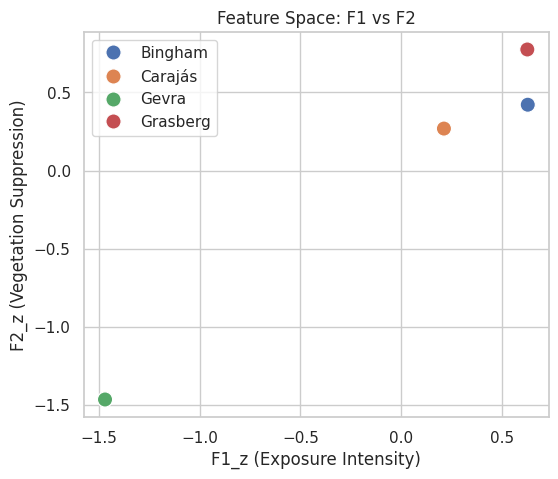

In [30]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=feature_df,
    x="F1_exposure_intensity_z",
    y="F2_vegetation_suppression_z",
    hue="asset",
    s=120
)

# Overlay centroids
centroids = kmeans.cluster_centers_

plt.xlabel("F1_z (Exposure Intensity)")
plt.ylabel("F2_z (Vegetation Suppression)")
plt.title("Feature Space: F1 vs F2")
plt.legend()
plt.show()

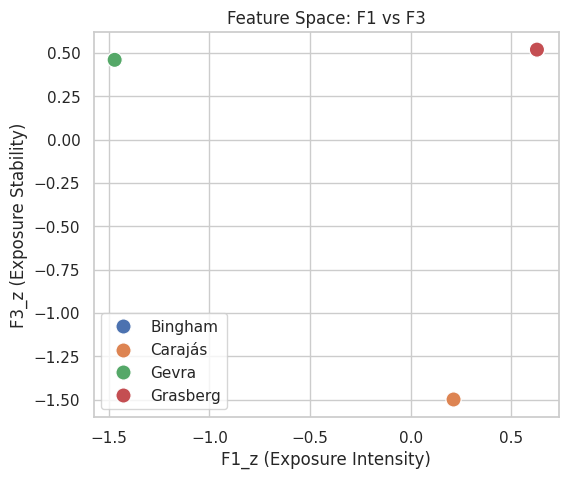

In [31]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=feature_df,
    x="F1_exposure_intensity_z",
    y="F3_persistence_raw_z",
    hue="asset",
    s=120
)

plt.xlabel("F1_z (Exposure Intensity)")
plt.ylabel("F3_z (Exposure Stability)")
plt.title("Feature Space: F1 vs F3")
plt.legend()
plt.show()

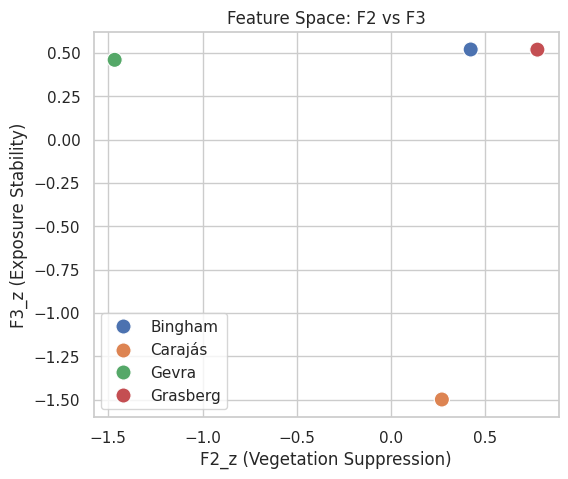

In [32]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=feature_df,
    x="F2_vegetation_suppression_z",
    y="F3_persistence_raw_z",
    hue="asset",
    s=120
)

plt.xlabel("F2_z (Vegetation Suppression)")
plt.ylabel("F3_z (Exposure Stability)")
plt.title("Feature Space: F2 vs F3")
plt.legend()
plt.show()

## Geometric Interpretation

Observations:

- Bingham and Grasberg are clearly separated in exposure-driven dimensions (F1, F2).
- Carajás and Gevra are closer in feature space, especially along F3 (stability).
- Separation margin between high-exposure and moderate-exposure assets is large.
- Margin between Carajás and Gevra is smaller.

Explanation of Weight Sensitivity Results:

- When F1 or F2 dominate, ranking remains stable due to strong geometric separation.
- When F3 dominates heavily, Carajás and Gevra can switch due to proximity along that axis.
- High-exposure assets remain invariant because their feature vectors are distant in multiple dimensions.

This confirms that robustness behavior observed in the stress test
is geometrically consistent with feature distribution.

## Geometry–Sensitivity Linkage

The extreme-weight stress test revealed that rankings remain stable
except when stability (F3) dominates heavily.

Feature space analysis explains this behavior:

- Bingham and Grasberg are geometrically separated
  across multiple dimensions (F1, F2, F3).
- Carajás and Gevra exhibit opposing profiles along F3.
- When stability weight dominates, their relative ordering shifts.

This confirms that sensitivity behavior is driven by
feature geometry rather than arbitrary model instability.

The composite score behaves predictably under
extreme feature emphasis.



---

# Phase 5 — Cluster Geometry & Decision Structure

To further understand the portfolio structure,
we visualize KMeans cluster assignments
in standardized feature space.

Clustering operates in geometric space.
Separation margins influence both
risk tiering and composite score stability.

We examine:

- Cluster grouping behavior
- Centroid positioning
- Structural separation across features

In [33]:
feature_df["cluster"] = kmeans.labels_
feature_df

,asset,F1_exposure_intensity,low_ndvi_variance,mean_ndvi,F2_vegetation_suppression,F3_persistence_raw,F1_exposure_intensity_z,F2_vegetation_suppression_z,F3_persistence_raw_z,CERI_z,risk_cluster,risk_tier,cluster
0,Bingham,0.999922,2.805335e-09,0.021179,0.978821,1.000000e+00,0.629904,0.421693,0.519958,0.545452,0,High Risk,0
1,Carajás,0.937332,2.050342e-03,0.035150,0.964850,4.877238e-07,0.213303,0.268879,-1.499415,-0.112568,0,High Risk,0
2,Gevra,0.684294,6.057728e-05,0.193744,0.806256,9.704564e-01,-1.470942,-1.465874,0.460299,-1.083173,1,Moderate Risk,1
3,Grasberg,0.999596,8.161065e-07,-0.011148,1.011148,9.996033e-01,0.627735,0.775302,0.519157,0.650290,0,High Risk,0


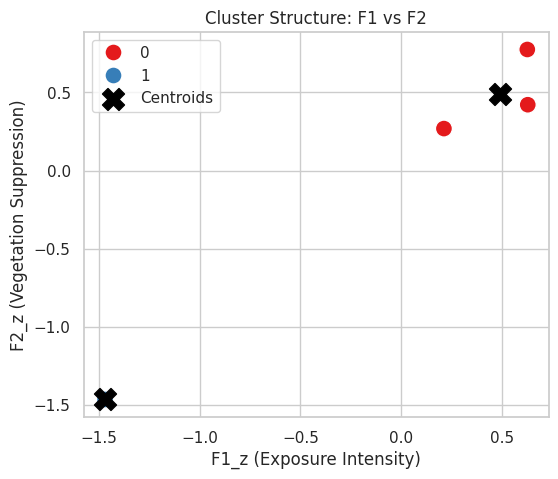

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.scatterplot(
    data=feature_df,
    x="F1_exposure_intensity_z",
    y="F2_vegetation_suppression_z",
    hue="cluster",
    palette="Set1",
    s=150
)

# Overlay centroids
centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='black',
    s=250,
    marker='X',
    label='Centroids'
)

plt.xlabel("F1_z (Exposure Intensity)")
plt.ylabel("F2_z (Vegetation Suppression)")
plt.title("Cluster Structure: F1 vs F2")
plt.legend()
plt.show()

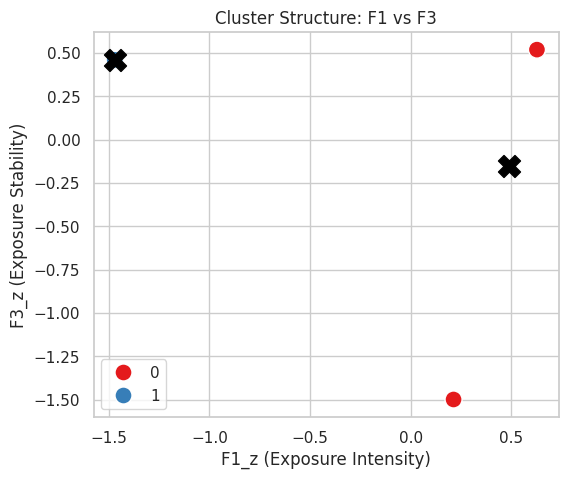

In [35]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=feature_df,
    x="F1_exposure_intensity_z",
    y="F3_persistence_raw_z",
    hue="cluster",
    palette="Set1",
    s=150
)

plt.scatter(
    centroids[:,0],
    centroids[:,2],
    c='black',
    s=250,
    marker='X'
)

plt.xlabel("F1_z (Exposure Intensity)")
plt.ylabel("F3_z (Exposure Stability)")
plt.title("Cluster Structure: F1 vs F3")
plt.legend()
plt.show()

## Cluster Interpretation

KMeans clustering identifies two structurally distinct tiers:

- High-exposure assets (Bingham, Grasberg)
- Moderate-exposure assets (Carajás, Gevra)

Centroids are separated primarily along F1 (Exposure Intensity),
with supporting separation along F2 (Suppression).

This explains:

- Why extreme weight shifts do not affect top-tier ordering
- Why only moderate-tier assets exhibit sensitivity
- Why clustering aligns with composite risk tiers

Geometric separation drives ranking robustness.

### Decision Boundary Intuition

KMeans partitions feature space based on Euclidean distance.

Because high-exposure assets are distant
from moderate-exposure assets across multiple dimensions,
the decision boundary lies between tiers
with substantial margin.

Large margin → ranking stability.

Small margin between Carajás and Gevra along F3
explains limited sensitivity under extreme stability weighting.

## Cluster Geometry Interpretation

KMeans clustering (k=2) isolates Gevra as a distinct asset,
while grouping Bingham, Grasberg, and Carajás together.

This indicates:

- Gevra is geometrically distant in standardized feature space.
- Carajás, despite lower stability (F3), remains closer
  to high-exposure assets in overall Euclidean distance.
- F1 and F2 contribute strongly to global separation.
- F3 influences ranking sensitivity but does not dominate
  clustering structure.

Clustering behavior confirms that exposure intensity
and vegetation suppression drive structural separation,
while stability contributes primarily to local ordering effects.



---
# Phase 5 — Cluster Validation via Silhouette Analysis

Clustering requires selection of k (number of clusters).

Rather than assuming k=2,
we evaluate clustering quality using silhouette score.

Silhouette score measures:

- Cohesion (within-cluster compactness)
- Separation (between-cluster distance)

Values range from -1 to 1:

- Close to 1 → well separated clusters
- Close to 0 → overlapping clusters
- Negative → misassigned clusters

We compare k = 2 and k = 3.


In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = feature_df[[
    "F1_exposure_intensity_z",
    "F2_vegetation_suppression_z",
    "F3_persistence_raw_z"
]].values

silhouette_results = []

for k in [2, 3]:
    kmeans_test = KMeans(n_clusters=k, random_state=42)
    labels = kmeans_test.fit_predict(X)
    score = silhouette_score(X, labels)

    silhouette_results.append({
        "k": k,
        "silhouette_score": score
    })

import pandas as pd
pd.DataFrame(silhouette_results)

,k,silhouette_score
0,2,0.373833
1,3,0.415581


In [37]:
kmeans_k3 = KMeans(n_clusters=3, random_state=42)
feature_df["cluster_k3"] = kmeans_k3.fit_predict(X)

feature_df[["asset", "cluster_k3"]]

,asset,cluster_k3
0,Bingham,2
1,Carajás,0
2,Gevra,1
3,Grasberg,2


### Cluster Validation (k=3)

Silhouette analysis suggested k=3 provides slightly better
separation than k=2.

KMeans (k=3) produced:

- Cluster 1: Bingham + Grasberg (High Exposure Tier)
- Cluster 2: Carajás (Moderate Exposure Tier)
- Cluster 3: Gevra (Lower Exposure Tier)

This indicates the portfolio naturally forms three
structurally distinct exposure groups.

The cluster structure aligns with CERI ranking tiers,
providing geometric validation of the composite score.